In [13]:
import scanpy as sc
import pandas
import seaborn
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas
import os
os.environ['R_HOME'] = '/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/R'
from rpy2.rinterface_lib import openrlib
openrlib.R_HOME = '/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/R'
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

In [3]:
sc._settings.settings._vector_friendly=True

In [12]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [8]:
%%R
library(EnhancedVolcano)
library(ggplot2)

In [9]:
scrna_out_file = '../data/scrna.h5ad'

In [10]:
adata = sc.read_h5ad(scrna_out_file)

# Figure 1

        Gene Probe_number            FDR    ProbeID
0       ADNP            4  1.412043e-201     ADNP;4
1       ADNP            1  5.160042e-100     ADNP;1
2      AEBP2            4   0.000000e+00    AEBP2;4
3      AEBP2            2  1.460023e-120    AEBP2;2
4       AFF1            1   0.000000e+00     AFF1;1
..       ...          ...            ...        ...
780  ZSCAN18            4  6.111856e-104  ZSCAN18;4
781  ZSCAN29            6   1.708188e-71  ZSCAN29;6
782  ZSCAN29            1   9.136615e-09  ZSCAN29;1
783     ZXDB            6  4.143240e-286     ZXDB;6
784     ZXDB            2   2.812018e-17     ZXDB;2

[664 rows x 4 columns]
        Gene Probe_number            FDR    ProbeID
0       ADNP            3   7.941048e-98     ADNP;3
1       ADNP            2   1.825137e-80     ADNP;2
2      AEBP2            1   1.018385e-18    AEBP2;1
3      AEBP2            6   8.052057e-05    AEBP2;6
5       AFF4            1   8.278794e-72     AFF4;1
..       ...          ...            ...

Text(0.5, 1.0, 'Avg. LogFC of top two gRNA hits.')

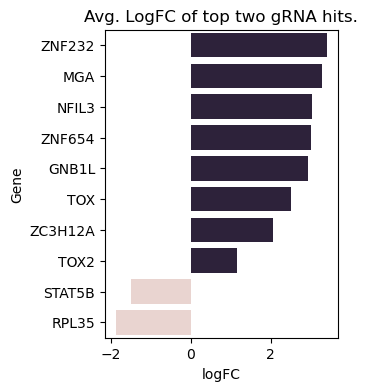

In [11]:
df_sig = pandas.read_excel("../data/Proj_13624_DiffAnalysis_Day20.baseline_.xlsx")
df_sig['Probe_number'] = [r['ProbeID'].split(';')[1] for i,r in df_sig.iterrows()]
df_sig = df_sig[df_sig['avg.baseline'].abs() > 20]

# Get top n hits per sample of positive hits
n_hits = 2

# Take top positives
df_sig_filtered_pos = df_sig[df_sig['logFC'] > 0].set_index('Probe_number').groupby('Gene')['FDR'].nsmallest(n_hits).reset_index()
df_sig_filtered_pos['ProbeID'] = df_sig_filtered_pos['Gene'] + ';' + df_sig_filtered_pos['Probe_number']
df_counts = df_sig_filtered_pos[['Gene']].value_counts().reset_index(name='count')
#df_counts = df_counts[df_counts[0]==n_hits]
df_counts = df_counts[df_counts['count']==n_hits]
df_sig_filtered_pos = df_sig_filtered_pos[df_sig_filtered_pos['Gene'].isin(df_counts['Gene'].values.tolist())]
print(df_sig_filtered_pos)

# Take top negatives
df_sig_filtered_neg = df_sig[df_sig['logFC'] < 0].set_index('Probe_number').groupby('Gene')['FDR'].nsmallest(n_hits).reset_index()
#df_sig_filtered_neg = df_sig.set_index('Probe_number').groupby('Gene')['FDR'].nsmallest(n_hits).reset_index()
df_sig_filtered_neg['ProbeID'] = df_sig_filtered_neg['Gene'] + ';' + df_sig_filtered_neg['Probe_number']
df_counts = df_sig_filtered_neg[['Gene']].value_counts().reset_index(name='count')
#df_counts = df_counts[df_counts[0]==n_hits]
df_counts = df_counts[df_counts['count']==n_hits]
df_sig_filtered_neg = df_sig_filtered_neg[df_sig_filtered_neg['Gene'].isin(df_counts['Gene'].values.tolist())]
print(df_sig_filtered_neg)

df_sig_mn_pos = df_sig[df_sig['ProbeID'].isin(df_sig_filtered_pos['ProbeID'].values)]
df_sig_mn_pos = df_sig_mn_pos[['Gene', 'logFC']].groupby('Gene').mean().reset_index()
df_sig_mn_pos = df_sig_mn_pos.sort_values(by='logFC', ascending=False)

df_sig_mn_neg = df_sig[df_sig['ProbeID'].isin(df_sig_filtered_neg['ProbeID'].values)]
df_sig_mn_neg = df_sig_mn_neg[['Gene', 'logFC']].groupby('Gene').mean().reset_index()
df_sig_mn_neg = df_sig_mn_neg.sort_values(by='logFC', ascending=False)

df_sig_mn = pandas.concat([df_sig_mn_pos[:5], df_sig_mn_pos[df_sig_mn_pos['Gene'].isin(['ZC3H12A', 'TOX', 'TOX2'])], 
                           df_sig_mn_neg[df_sig_mn_neg['Gene'].isin(['STAT5B', 'RPL35'])]])
df_sig_mn['sign'] = np.sign(df_sig_mn['logFC'])
df_sig_mn

plt.figure(figsize=(3,4))
seaborn.barplot(data=df_sig_mn, y='Gene', x='logFC', hue='sign')
plt.legend('',frameon=False)
plt.title("Avg. LogFC of top two gRNA hits.")
#plt.savefig("figures/grna_hits.pdf", transparent=True)

In [19]:
select_genes = df_sig_mn['Gene'].unique().tolist()

df_sig_ranked = df_sig.copy()
df_sig_ranked = df_sig_ranked.sort_values(by='logFC', ascending=False)
rnks = []
rank_counter = {}
for g in df_sig_ranked['Gene'].unique():
    rank_counter[g] = 0
for i,r in df_sig_ranked.iterrows():
    rank_counter[r['Gene']] += 1
    rnks.append(rank_counter[r['Gene']])
df_sig_ranked['rank'] = rnks
#df_sig_ranked = df_sig_ranked[df_sig_ranked['rank'] < 3]
df_sig_ranked['Gene_rnk'] = df_sig_ranked['Gene'].values.tolist()

# reverse ranking of STAT5B, TOX2, and RPL35
df_sig_ranked.loc[df_sig_ranked['Gene']=='STAT5B', 'rank'] = df_sig_ranked[df_sig_ranked['Gene']=='STAT5B']['rank'].max() - df_sig_ranked[df_sig_ranked['Gene']=='STAT5B']['rank'] + 1
df_sig_ranked.loc[df_sig_ranked['Gene']=='RPL35', 'rank'] = df_sig_ranked[df_sig_ranked['Gene']=='RPL35']['rank'].max() - df_sig_ranked[df_sig_ranked['Gene']=='RPL35']['rank'] + 1
df_sig_ranked.loc[df_sig_ranked['Gene']=='TOX2', 'rank'] = df_sig_ranked[df_sig_ranked['Gene']=='TOX2']['rank'].max() - df_sig_ranked[df_sig_ranked['Gene']=='TOX2']['rank'] + 1


df_sig_ranked.loc[df_sig_ranked['rank'] > 2, 'Gene_rnk'] = ''

In addition: Warning message:
One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value... 


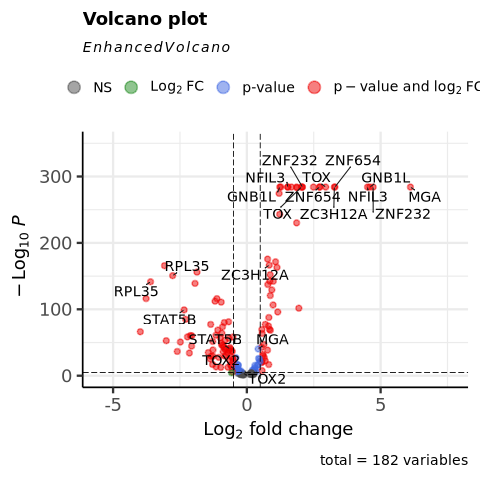

In [20]:
%%R -w 1000 -h 800 -i select_genes,df_sig_ranked
labels <- select_genes
labels1 <- c(labels, grep('HumanControl', df_sig_ranked$Gene_rnk, value=TRUE))
df_sig_f <- df_sig_ranked[df_sig_ranked$Gene_rnk %in% labels1,]
p <- EnhancedVolcano(df_sig_f,
    lab = df_sig_f$Gene_rnk,
    x = 'logFC',
    y = 'FDR',
    drawConnectors = TRUE, 
    selectLab=labels,
    boxedLabels=FALSE, labSize = 5.0,
    lengthConnectors=unit(0.001, 'npc'), widthConnectors=0.5,
    max.overlaps = Inf, FCcutoff = 0.5,
    ylim = c(0,350))
p
#ggsave(filename="figures/volcano_hits.pdf", plot=p, width=18, height=17, units='cm')

/tmp/ipykernel_1726421/1558279385.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p['sign'] = 0


Text(0.5, 0, 'logFC')

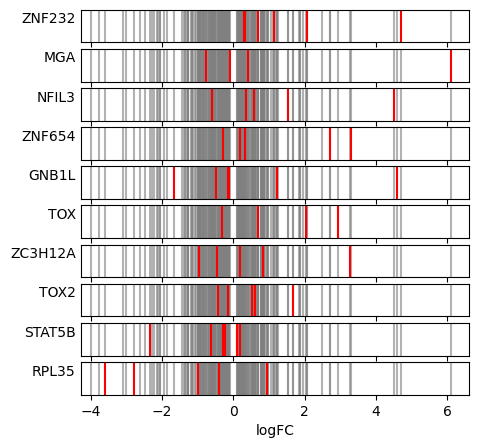

In [21]:
df_p = df_sig[(df_sig['Gene'].isin(select_genes))|(df_sig['Gene'].str.startswith('HumanControl'))]
fig, ax = plt.subplots(len(select_genes), 1, figsize=(5, 5), sharex=True)
for g_idx in range(len(select_genes)):
    g = select_genes[g_idx]
    #plt.figure(figsize=(5,1))
    df_p['sign'] = 0
    df_p.loc[df_p['Gene']==g, 'sign'] = 1
    df_p = df_p.sort_values(by='sign')
    for i,r in df_p.iterrows():
        c = 'red' if r['Gene']==g else 'grey'
        a = 1 if r['Gene']==g else 0.6
        ax[g_idx].axvline(r['logFC'], color=c, alpha=a)
    ax[g_idx].set_ylabel(g)
    ax[g_idx].set_yticks([])
    ax[g_idx].yaxis.label.set(rotation='horizontal', ha='right')
ax[g_idx].set_xlabel('logFC')
#plt.savefig("figures/grna_hits_all.pdf", transparent=True)

# Figure 7

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


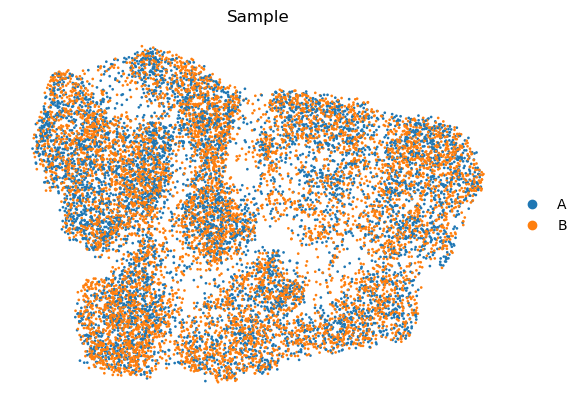

In [22]:
sc.pl.umap(adata, color='Sample', frameon=False, size=15)

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


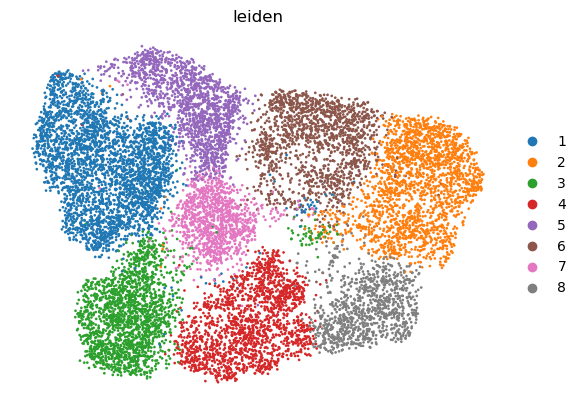

In [23]:
sc.pl.umap(adata, color='leiden', frameon=False, size=15)

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


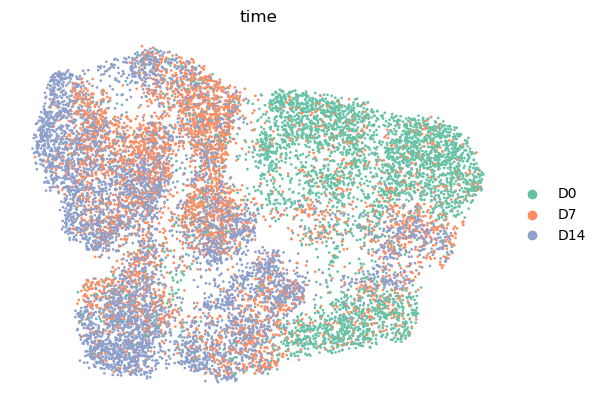

In [24]:
sc.pl.umap(adata, color='time', frameon=False, size=15,
           palette=seaborn.color_palette("Set2").as_hex()[:3])

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


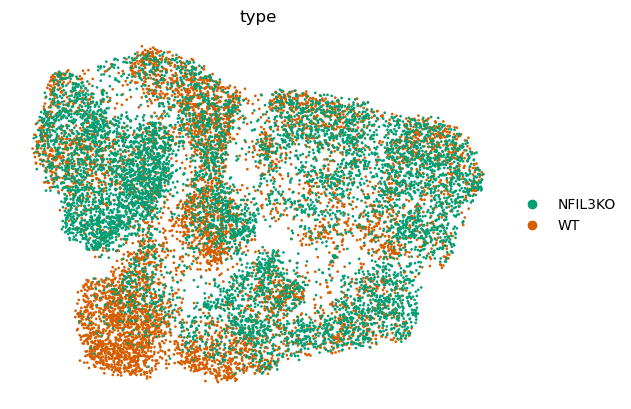

In [61]:
sc.pl.umap(adata, color='type', frameon=False, size=15,
           palette=[seaborn.color_palette("colorblind").as_hex()[2], seaborn.color_palette("colorblind").as_hex()[3]])

In [25]:
sc.tl.embedding_density(adata, groupby='type')

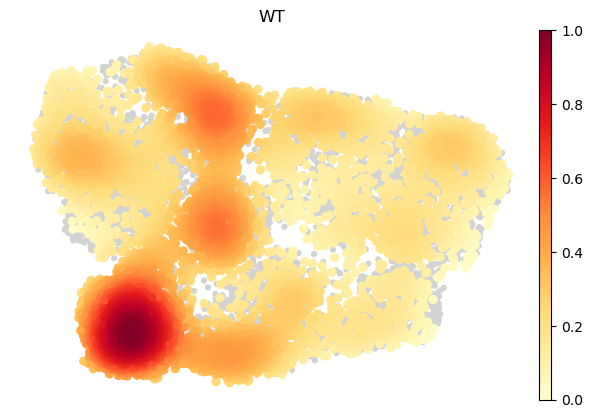

In [26]:
sc.pl.embedding_density(adata, basis='umap', key='umap_density_type', group='WT', frameon=False)

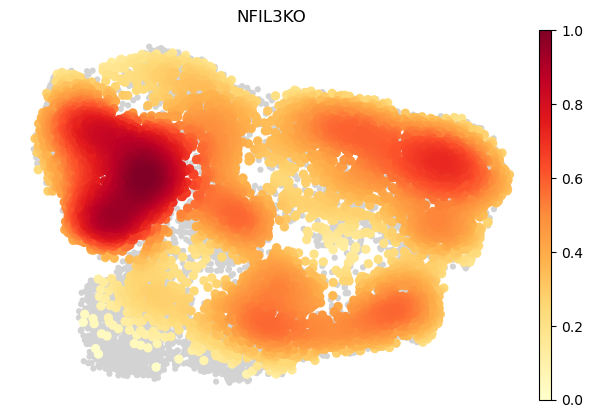

In [27]:
sc.pl.embedding_density(adata, basis='umap', key='umap_density_type', group='NFIL3KO', frameon=False)

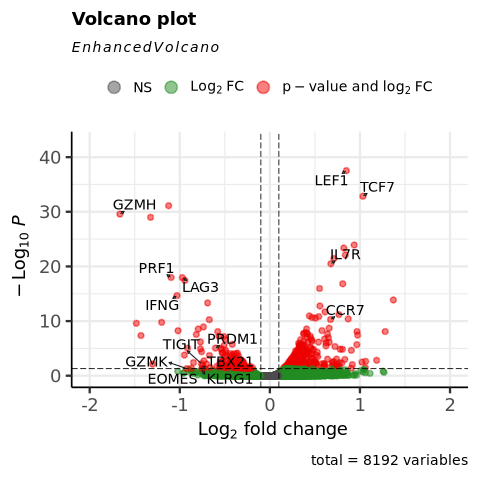

In [28]:
%%R
tbl <- read.table('../data/deg_0_vs_2_wilcoxon_filtered.csv', sep='\t', header=TRUE)
EnhancedVolcano(tbl,
    lab = tbl$names,
    x = 'logfoldchanges',
    y = 'pvals_adj',
    selectLab = c('LEF1', 'TCF7', 'IL7R', 'SELL', 'LAT', 'CCR7', 'ZEB2', 'PRDM1',
                  'EOMES', 'TBX21', 'TIGIT', 'KLRG1', 'NFATC2', 'GZMK', 'IFNG', 
                  'PRF1', 'GZMH', 'GZMB', 'GZMA', 'LAG3'),
    drawConnectors = TRUE, xlim=c(-2, 2), FCcutoff=0.1, pCutoff=0.05, max.overlaps = 20)

      rank leiden       TF
7        7      1  LEF1(+)
238     65      2  LEF1(+)
466    120      3  LEF1(+)
581     62      4  LEF1(+)
692      0      5  LEF1(+)
928     63      6  LEF1(+)
1147   109      7  LEF1(+)
1303    92      8  LEF1(+)


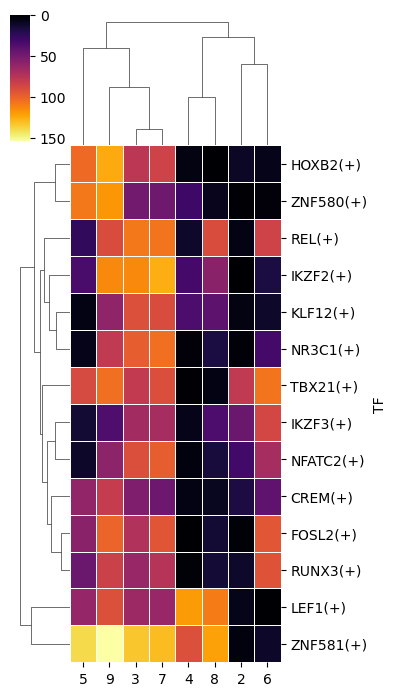

In [44]:
rss_leiden = pandas.read_csv('../data/scrna_pyscenic_rss.csv', sep='\t', index_col=0)
rss_leiden.index = [x+1 for x in rss_leiden.index]
rss_leiden.index = rss_leiden.index.astype(str)

cats = sorted(list(set(adata.obs['leiden'])))

topreg = []
for i,c in enumerate(cats):
    if c != '1' and c != '3': continue
    topreg.extend(
        list(rss_leiden.T[c].sort_values(ascending=False)[:8].index)
    )
topreg = list(set(topreg))

topreg_rank = []
ranks = []
celltypes = []
for i,c in enumerate(cats):
    topreg_rank.extend(
        list(rss_leiden.T[c].sort_values(ascending=False).index)
    )
    ranks.extend(np.arange(rss_leiden.shape[1]).tolist())
    celltypes.extend([c]*rss_leiden.shape[1])
topreg_rank_df = pandas.DataFrame(columns=['rank', 'leiden', 'TF'])
topreg_rank_df['rank'] = ranks
topreg_rank_df['leiden'] = celltypes
topreg_rank_df['TF'] = topreg_rank
print(topreg_rank_df[topreg_rank_df['TF'].str.contains('LEF1')])
topreg_rank_df = topreg_rank_df[topreg_rank_df['TF'].isin(topreg)]
topreg_rank_df = topreg_rank_df.pivot(index='TF', columns='leiden', values='rank')
topreg_rank_df.columns = [str(int(x)+1) for x in topreg_rank_df.columns]
g = seaborn.clustermap(topreg_rank_df, cmap='inferno', figsize=(4,7), linecolor='white', linewidths=0.5)
cbar_ax = g.ax_cbar
cbar_ax.invert_yaxis()
#plt.savefig("./figures/top8_ranking_all_clusters.pdf", dpi=600, bbox_inches = "tight")

In [46]:
genes = {'LEF1': ['TCF7', 'LRRN3', 'VOPP1', 'LEF1-AS1', 'RAB11A', 'TMEM123', 'TESPA1', 'SYPL1', 'ACTN1', 'IKZF2',
          'NAP1L4', 'HMGA1', 'TOX2', 'SESN3', 'MRPL14', 'SORL1', 'CCR7', 'MSL3', 'CAPG', 'IL16', 'TBC1D4',
          'PIK3CA', 'CPNE2', 'TRABD2A', 'PLCL2', 'TRIM44', 'CYP1B1', 'SPATC1L', 'FXYD2', 'TRAF3IP2', 'MTA3',
          'NFATC1', 'TSPAN33', 'CCDC106', 'MYB', 'TRIB2', 'SMIM8', 'TM7SF2', 'TGIF2', 'CDR2', 'ZAP70', 'GKAP1',
          'EIF2D', 'KLF4', 'LEF1', 'RBL2', 'DECR1', 'BCL6', 'BRD3', 'CHST7', 'SPAG16', 'GNPDA1', 'FAM162A', 'SKP1',
          'MARCH2', 'TOMM22', 'LINC01089'],
'TBX21': ['DNAAF2', 'CASP7', 'EAF1', 'NAA30', 'C16orf87', 'ATG2A', 'RAB11FIP4', 'LYAR', 'CARNMT1', 'IRF2BPL', 'BMI1',
          'PLEKHF1', 'C5orf56', 'RCBTB2', 'CDKN2AIP', 'GAB3', 'STK40', 'TRAF5', 'ID2', 'KLF10', 'F2R', 'GADD45G', 'PNMA1',
          'GADD45B', 'PILRB', 'ZFYVE28', 'APOBEC3G', 'FRMD4B', 'HDLBP', 'HOPX', 'APOBEC3H', 'SMIM13', 'PMEPA1', 'HAUS3', 'GPR183',
          'SRSF7', 'HLA-DRB1', 'EFHD2', 'DDI2', 'C1orf21', 'SMAD7']}

Text(0.5, 1.0, 'TBX21 genes')

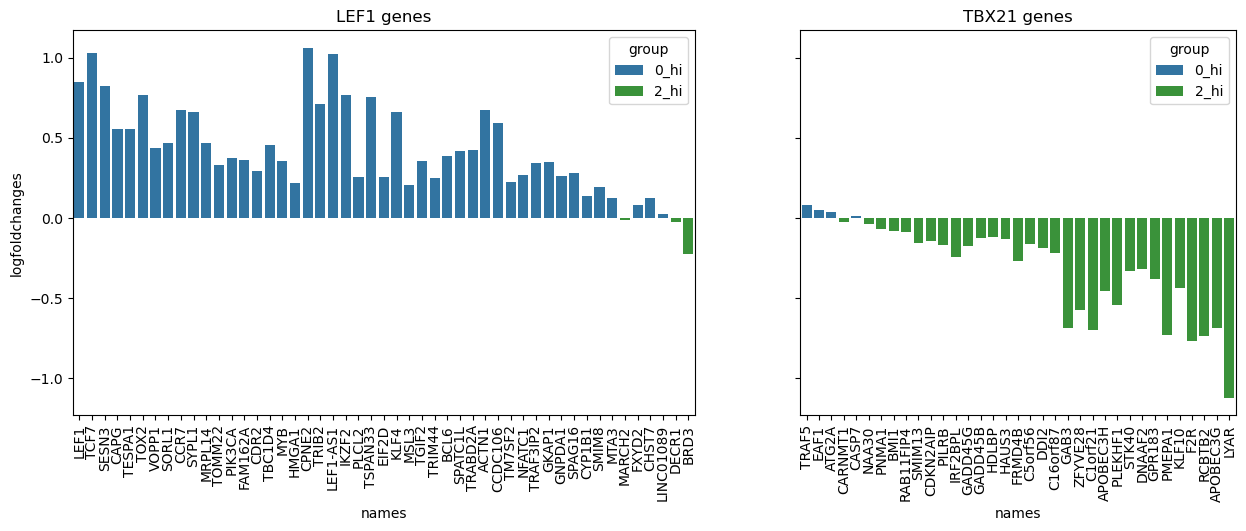

In [49]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 5), width_ratios=[1,0.7])
degs_0_vs_2 = pandas.read_csv('../data/deg_0_vs_2_wilcoxon_filtered.csv', sep='\t')

degs_0_vs_2['group'] = ['0_hi' if r['logfoldchanges'] > 0 else '2_hi' for i,r in degs_0_vs_2.iterrows()]

seaborn.barplot(data=degs_0_vs_2[degs_0_vs_2['names'].isin(genes['LEF1'])], x='names', y='logfoldchanges', ax=ax[0],
            hue='group', palette={'0_hi': 'tab:blue', '2_hi': 'tab:green'})
            #   color='tab:blue')
seaborn.barplot(data=degs_0_vs_2[degs_0_vs_2['names'].isin(genes['TBX21'])], x='names', y='logfoldchanges', ax=ax[1],
            hue='group', palette={'0_hi': 'tab:blue', '2_hi': 'tab:green'})
            #   color='tab:green')

ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)
ax[0].set_title('LEF1 genes')
ax[1].set_title('TBX21 genes')
#plt.savefig("./figures/regulons_plot.pdf", dpi=600, bbox_inches = "tight")

In [51]:
def calc_significance_gene_score_celltypes(adata, c1, c2, gene_score, clabel, alternative='two-sided'):
    v1 = adata.obs[adata.obs[clabel]==c1][gene_score].values
    v2 = adata.obs[adata.obs[clabel]==c2][gene_score].values
    _, pv = stats.ranksums(v1, v2, alternative=alternative)
    print(gene_score, "Wilcoxon rank-sum:", c1, c2, pv, "alternative:", alternative)

In [52]:
adata_sub = adata[adata.obs['leiden'].isin(['1', '3'])].copy()
sc.pp.filter_genes(adata_sub, min_cells=100)

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.

Good_dysfunctional Wilcoxon rank-sum: 3 1 4.006294945950051e-46 alternative: greater
Good_dysfunctional Wilcoxon rank-sum: 3 1 5.488891789674787e-11 alternative: greater


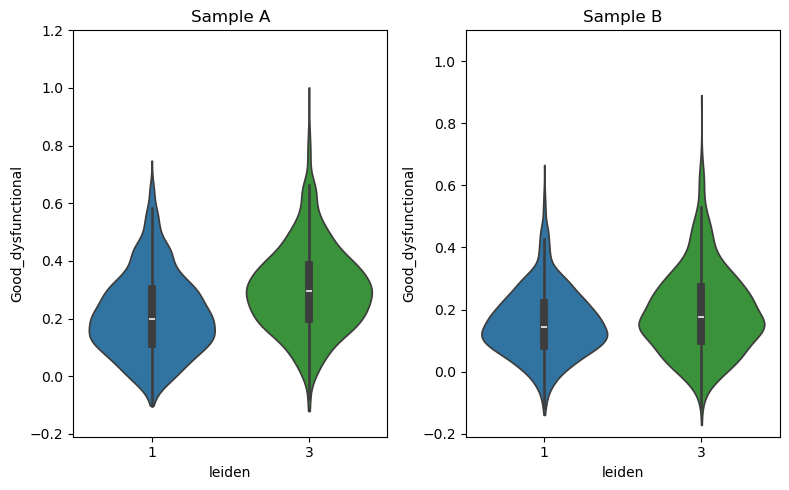

In [54]:
# table S4 from Good et al., Cell 2021
tbl_s4 = pandas.read_excel("/data1/lesliec/sneha/data/Good_car_nk_2021/tableS4.xlsx")
dys = tbl_s4[(tbl_s4['avg_logFC'] > 0.5) & (tbl_s4['p_val_adj'] < 0.05)]['Gene'].values
sc.tl.score_genes(adata_sub, dys, score_name='Good_dysfunctional', n_bins=10, use_raw=True)

fig, ax = plt.subplots(1, 2, figsize=(8,5))
sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='A')], 'Good_dysfunctional', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[0], show=False)
sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='B')], 'Good_dysfunctional', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[1], show=False)
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='A')], '3', '1', 'Good_dysfunctional', 'leiden', alternative='greater')
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='B')], '3', '1', 'Good_dysfunctional', 'leiden', alternative='greater')
ax[0].set_ylim((-0.21, 1.2))
ax[1].set_ylim((-0.21, 1.1))
ax[0].set_title('Sample A')
ax[1].set_title('Sample B')

plt.tight_layout()
#plt.savefig("./figures/good_dys_signature.pdf", dpi=600, bbox_inches = "tight")

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.

Sample A:
Deng_CR Wilcoxon rank-sum: 1 3 1.8168107771808592e-33 alternative: greater
Sample A:
Deng_PR_PD Wilcoxon rank-sum: 3 1 1.0768611715098643e-108 alternative: greater
Sample B:
Deng_CR Wilcoxon rank-sum: 1 3 1.3972666752639473e-37 alternative: greater
Sample B:
Deng_PR_PD Wilcoxon rank-sum: 3 1 0.024101789467976656 alternative: greater


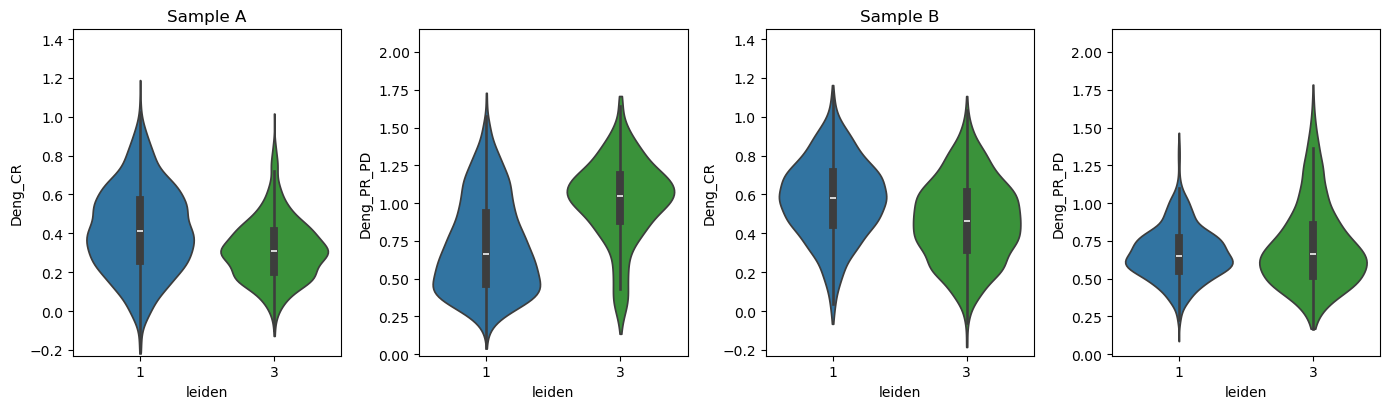

In [57]:
# table from Deng et al., Nat Med 2020
tbl = pandas.read_excel("/data1/lesliec/sneha/data/Deng_car_eff_tox_2020/supp_tbl.xlsx", sheet_name=2)
tbl.columns = tbl.iloc[2]
tbl = tbl.drop(0)
tbl = tbl.drop(1)
tbl = tbl.drop(2)
cr = tbl[tbl['avg_logFC'] > 0]['Gene'].values
pr_pd = tbl[tbl['avg_logFC'] < 0]['Gene'].values

sc.tl.score_genes(adata_sub, cr, score_name='Deng_CR', n_bins=10, use_raw=True)
sc.tl.score_genes(adata_sub, pr_pd, score_name='Deng_PR_PD', n_bins=10, use_raw=True)

# Share this
fig, ax = plt.subplots(1, 4, figsize=(14,4.2))
#sc.pl.violin(adata_sub, adata_sub.obs.columns[adata_sub.obs.columns.str.startswith('Good_')], groupby='leiden', inner='box', stripplot=False)
sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='A')], 'Deng_CR', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[0], show=False)
sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='A')], 'Deng_PR_PD', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[1], show=False)

sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='B')], 'Deng_CR', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[2], show=False)
sc.pl.violin(adata_sub[(adata_sub.obs['Sample']=='B')], 'Deng_PR_PD', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[3], show=False)

print("Sample A:")
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='A')], '1', '3', 'Deng_CR', 'leiden', alternative='greater')
print("Sample A:")
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='A')], '3', '1', 'Deng_PR_PD', 'leiden', alternative='greater')
print("Sample B:")
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='B')], '1', '3', 'Deng_CR', 'leiden', alternative='greater')
print("Sample B:")
calc_significance_gene_score_celltypes(adata_sub[(adata_sub.obs['Sample']=='B')], '3', '1', 'Deng_PR_PD', 'leiden', alternative='greater')
ax[0].set_ylim((-0.23, 1.45))
ax[1].set_ylim((-0.01, 2.15))
ax[2].set_ylim((-0.23, 1.45))
ax[3].set_ylim((-0.01, 2.15))
ax[0].set_title('Sample A')
ax[2].set_title('Sample B')

plt.tight_layout()
#plt.savefig("./figures/good_Deng_signature.pdf", dpi=600, bbox_inches = "tight")

# Figure S8

<Axes: xlabel='leiden', ylabel='count'>

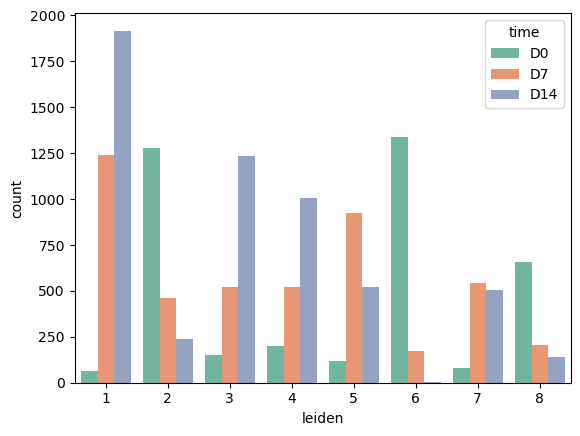

In [58]:
seaborn.countplot(data=adata.obs, x='leiden', hue='time', palette=adata.uns['time_colors'])
#plt.savefig('figures/leiden_counts.pdf', transparent=True)

<Axes: xlabel='leiden', ylabel='count'>

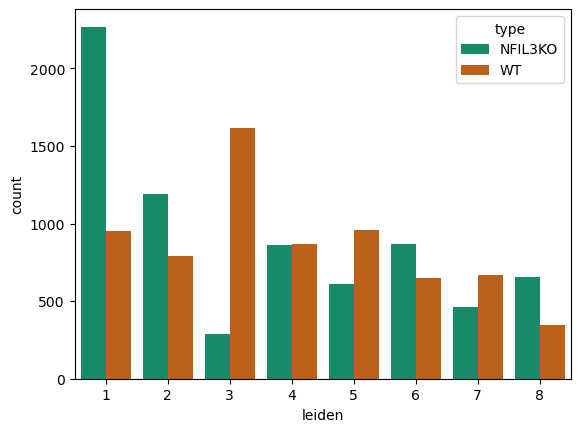

In [62]:
seaborn.countplot(data=adata.obs, x='leiden', hue='type', palette=adata.uns['type_colors'])
#plt.savefig('figures/leiden_type_counts.pdf', transparent=True)

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 16.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 27.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 17.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warn

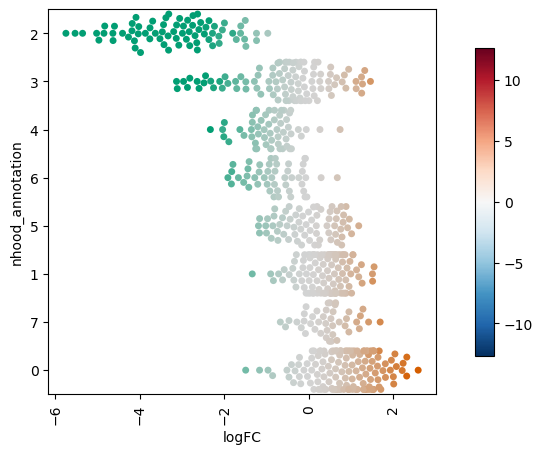

In [64]:
df = pandas.read_csv("../data/milo_out.csv", sep='\t')
min_max = min(abs(df['-log10(SpatialFDR)'].min()), df['-log10(SpatialFDR)'].max())
norm = plt.Normalize(-min_max, min_max) # -0.3, 0.3) # df_tumor_t['-log10(FDR)'].min(), df_tumor_t['-log10(FDR)'].max())
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
plt.figure(figsize=(5,5))
g = seaborn.swarmplot(data=df[df['nhood_annotation']!='Mixed'], x="logFC", y="nhood_annotation", hue='-log10(SpatialFDR)', 
                      palette="blend:#029e73,lightgrey,#d55e00",
                      #palette=seaborn.color_palette(['#1f77b4', 'lightgrey', '#ff7f0e'], 3, n_colors=30), #'RdBu_r', 
                      hue_norm=norm,
                     #order=['2', '3', '4', '6', 'Mixed', '5', '1', '7', '0'],
                     order=['2', '3', '4', '6', '5', '1', '7', '0'],
                     )
sm.set_array([])
cax=plt.gca().inset_axes([1.1, 0.1, 0.05, 0.8])
plt.gca().get_legend().remove()
g.get_figure().colorbar(sm, cax)
plt.gca().tick_params(axis='x', rotation=90)
#plt.savefig('figures/milo_out.pdf', transparent=True)

In [66]:
def calc_pvals(adata, c1, c2, alt=None):
    v1 = adata[adata.obs['time_type']==c1].obs['Treg_score'].values
    v2 = adata[adata.obs['time_type']==c2].obs['Treg_score'].values
    if alt is None:
        _, pv = stats.ranksums(v1, v2) # , alternative='greater')
    else:
        _, pv = stats.ranksums(v1, v2, alternative=alt)
    print(c1, c2, pv)

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


(-0.21, 1.3)

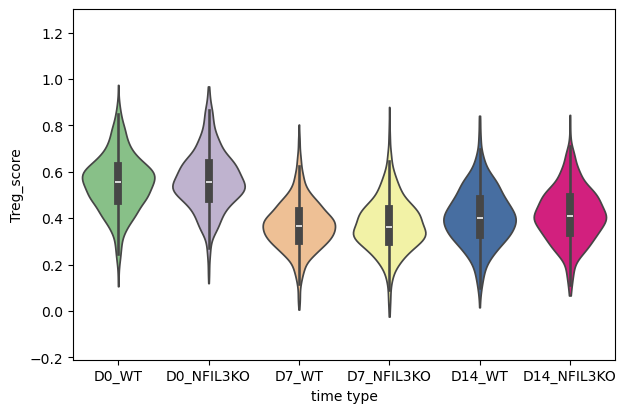

In [67]:
# Treg signature from Bai et al., Nature 2024
signatures = pandas.read_csv('/data1/lesliec/sneha/data/Bai_car_cd4_2024/41586_2024_7762_MOESM6_ESM.csv', sep=',')
signatures = signatures.sort_values(by='avg_log2FC', ascending=False)
signatures_treg = signatures[(signatures['avg_log2FC'] > 0.5) & (signatures['p_val_adj'] < 0.05) & (signatures['cluster']==14)]

adata_cd4 = adata[(adata.obs['CD4_CD8']=='CD4')].copy()
sc.tl.score_genes(adata_cd4, signatures_treg['Gene'].values.tolist(), score_name='Treg_score')

adata_cd4.obs['time_type'] = [r['time'] + '_' + r['type'] for i,r in adata_cd4.obs.iterrows()]

sc.pl.violin(adata_cd4, 'Treg_score', groupby='time_type', show=False, inner='box', stripplot=False, palette='Accent',
            order=['D0_WT', 'D0_NFIL3KO', 'D7_WT', 'D7_NFIL3KO', 'D14_WT', 'D14_NFIL3KO'])
plt.ylim((-0.21, 1.3))
#plt.savefig('./figures/timepoints_treg_score.pdf')

In [68]:
for c in ['D0', 'D7', 'D14']:
    c1 = c + '_NFIL3KO'
    c2 = c + '_WT'
    calc_pvals(adata_cd4, c1, c2, 'two-sided')

D0_NFIL3KO D0_WT 0.10134464958965456
D7_NFIL3KO D7_WT 0.9434104473237205
D14_NFIL3KO D14_WT 0.15839406255931354


/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_anndata.

Tpex_signature Wilcoxon rank-sum: 1 3 5.196903402553412e-57 alternative: greater
Tpex_signature Wilcoxon rank-sum: 1 3 3.939005679317098e-07 alternative: greater


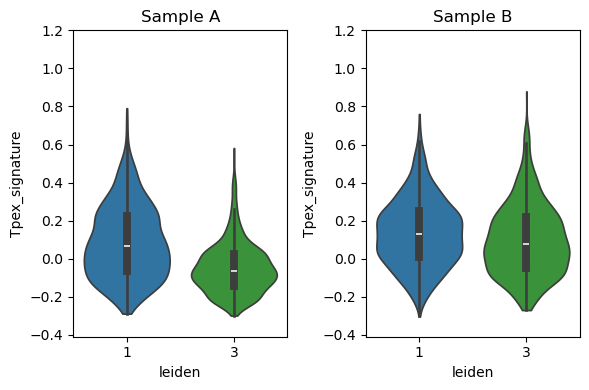

In [71]:
adata_sub_cd8 = adata_sub[adata_sub.obs['CD4_CD8']=='CD8'].copy()
adata_cd8 = adata[adata.obs['CD4_CD8']=='CD8'].copy()
adata_cd4 = adata[adata.obs['CD4_CD8']=='CD4'].copy()
adata_cd8.obs['time_type'] = [r['time'] + '_' + r['type'] for i,r in adata_cd8.obs.iterrows()]
# Tpex signature from Masopust et al., Nat Rev Imm 2025
tpex_signature = ['PDCD1', 'TOX', 'TCF7', 'BCL6', 'SLAMF6', 'CXCR3', 'LEF1', 'CD28', 'NT5E', 'XCL1', 'CXCR5']

sc.tl.score_genes(adata_sub_cd8, tpex_signature, score_name='Tpex_signature', n_bins=10, use_raw=True)

# Share this
fig, ax = plt.subplots(1, 2, figsize=(6,4))
#sc.pl.violin(adata_sub, adata_sub.obs.columns[adata_sub.obs.columns.str.startswith('Good_')], groupby='leiden', inner='box', stripplot=False)
sc.pl.violin(adata_sub_cd8[(adata_sub_cd8.obs['Sample']=='A')], 'Tpex_signature', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[0], show=False)
sc.pl.violin(adata_sub_cd8[(adata_sub_cd8.obs['Sample']=='B')], 'Tpex_signature', 
             groupby='leiden', inner='box', stripplot=False, ax=ax[1], show=False)
calc_significance_gene_score_celltypes(adata_sub_cd8[(adata_sub_cd8.obs['Sample']=='A')], '1', '3', 'Tpex_signature', 'leiden', alternative='greater')
calc_significance_gene_score_celltypes(adata_sub_cd8[(adata_sub_cd8.obs['Sample']=='B')], '1', '3', 'Tpex_signature', 'leiden', alternative='greater')
ax[0].set_ylim((-0.41, 1.2))
ax[1].set_ylim((-0.41, 1.2))
ax[0].set_title('Sample A')
ax[1].set_title('Sample B')

plt.tight_layout()
#plt.savefig("./figures/tpex_signature_1_3.pdf", dpi=600, bbox_inches = "tight")